# Notebook 1: EDA + Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from itertools import product
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=0.9)
pd.set_option('display.max_columns', 80)

In [2]:
df = pd.read_parquet('../data/processed/matches.parquet')
df.shape

(100041, 472)

## basic stats

In [3]:
display(df.dtypes.value_counts().rename('count'))
nan_cols = df.isna().sum()
display(nan_cols[nan_cols > 0].sort_values(ascending=False).head(10))

float64    395
int64       77
Name: count, dtype: int64

t1_p0_damage_taken_per_soul    18
t1_p0_damage_per_soul          18
t1_p0_obj_damage_per_soul      18
t1_p1_obj_damage_per_soul      17
t1_p1_damage_taken_per_soul    17
t1_p1_damage_per_soul          17
t0_p4_damage_per_soul          15
t0_p4_obj_damage_per_soul      15
t0_p4_damage_taken_per_soul    15
t1_p3_damage_per_soul          14
dtype: int64

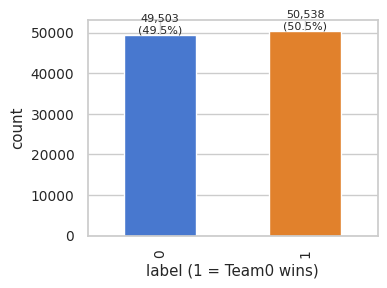

In [4]:
# label distribution
label_counts = df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
label_counts.plot.bar(ax=ax, color=['#4878cf', '#e1812c'])
ax.set_xlabel('label (1 = Team0 wins)')
ax.set_ylabel('count')
for i, v in enumerate(label_counts):
    ax.text(i, v + 300, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## leakage audit

In [5]:
# redundancy check before finalising drop list
corr_badge_mmr = df['average_badge_team0'].corr(df['t0_avg_mmr_rank'])
corr_herowr_label = df['t0_avg_player_hero_wr'].corr(df['label'])
pd.Series({'corr(average_badge, avg_mmr_rank)': corr_badge_mmr,
           'corr(player_hero_wr, label)': corr_herowr_label}).round(4)

corr(average_badge, avg_mmr_rank)    0.9929
corr(player_hero_wr, label)          0.7780
dtype: float64

In [6]:
drop_leakage    = ['winning_team', 'duration_s']
drop_id         = (['match_id', 'start_time']
                   + [f't{t}_p{p}_account_id'  for t in range(2) for p in range(6)]
                   + [f't{t}_p{p}_player_slot'  for t in range(2) for p in range(6)])
drop_zero_var   = ['game_mode']
drop_redundant  = ['average_badge_team0', 'average_badge_team1']  # r=0.993 with avg_mmr_rank
drop_temporal   = [f't{t}_p{p}_last_played' for t in range(2) for p in range(6)]
drop_fixed      = [f't{t}_p{p}_assigned_lane' for t in range(2) for p in range(6)]  # always 2-2-2

all_drop = drop_leakage + drop_id + drop_zero_var + drop_redundant + drop_temporal + drop_fixed

hero_cols = [f't{t}_p{p}_hero_id' for t in range(2) for p in range(6)]
valid_mask = ~df[hero_cols].isna().any(axis=1)
df = df[valid_mask].reset_index(drop=True)

y        = df['label'].copy()
df_clean = df.drop(columns=all_drop + ['label'])
df_clean.shape

(100039, 416)

## feature distributions

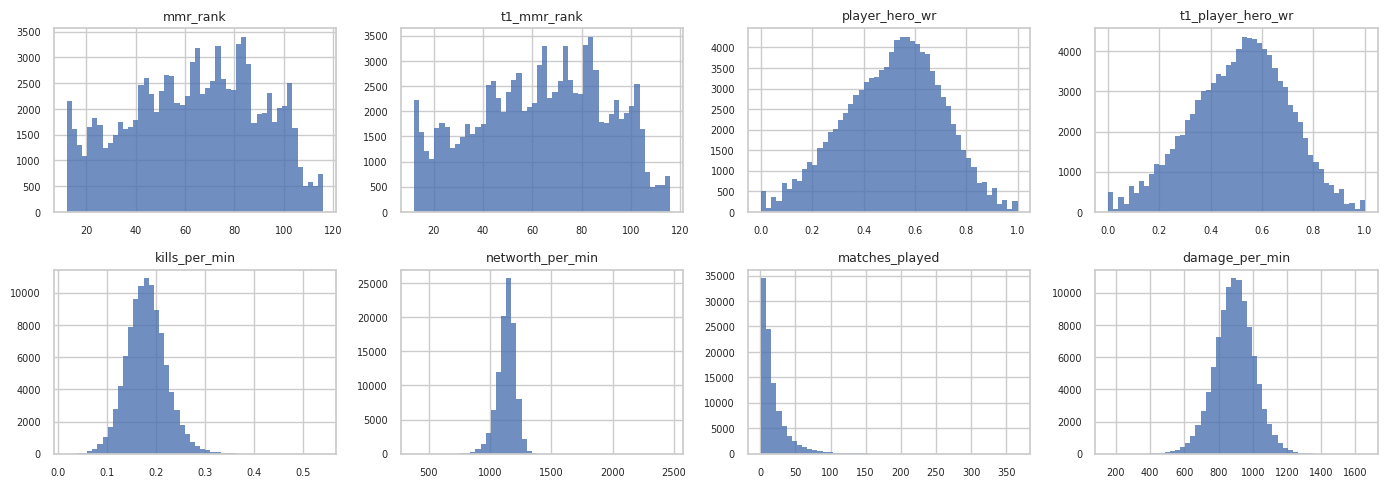

In [7]:
team_agg_cols = [c for c in df_clean.columns if c.startswith(('t0_avg_', 't1_avg_'))]
key_features  = ['t0_avg_mmr_rank', 't1_avg_mmr_rank',
                 't0_avg_player_hero_wr', 't1_avg_player_hero_wr',
                 't0_avg_kills_per_min', 't0_avg_networth_per_min',
                 't0_avg_matches_played', 't0_avg_damage_per_min']

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, col in zip(axes.flat, key_features):
    df_clean[col].hist(bins=50, ax=ax, edgecolor='none', alpha=0.8)
    ax.set_title(col.replace('t0_avg_', '').replace('t1_avg_', 't1_'), fontsize=9)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

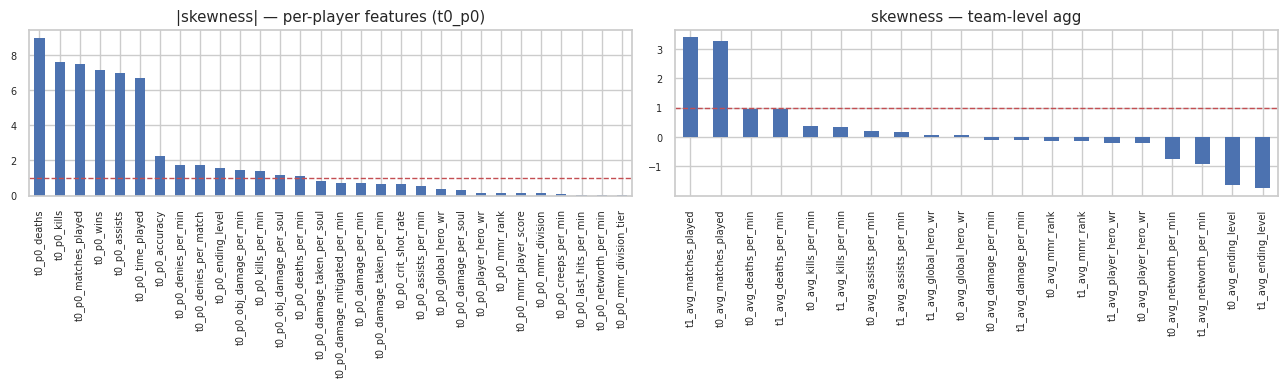

In [8]:
# per-player skewness (t0_p0 representative) + team-level
per_player_cols = [c for c in df_clean.columns if c.startswith('t0_p0_') and df_clean[c].dtype == 'float64']
skew_per_player = df_clean[per_player_cols].skew().abs().sort_values(ascending=False).rename('|skew|')
skew_team_agg   = df_clean[team_agg_cols].skew().sort_values(ascending=False).rename('skew')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
skew_per_player.plot.bar(ax=axes[0], edgecolor='none')
axes[0].axhline(1, color='r', lw=1, ls='--')
axes[0].set_title('|skewness| — per-player features (t0_p0)')
axes[0].tick_params(labelsize=7)
skew_team_agg.plot.bar(ax=axes[1], edgecolor='none')
axes[1].axhline(1, color='r', lw=1, ls='--')
axes[1].set_title('skewness — team-level agg')
axes[1].tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [9]:
# slot consistency: skew_std should be low across 12 slots
base_fields = [c.replace('t0_p0_', '') for c in per_player_cols]
rows = []
for f in base_fields:
    s = [df_clean[f't{t}_p{p}_{f}'].skew() for t, p in product(range(2), range(6))
         if f't{t}_p{p}_{f}' in df_clean.columns]
    rows.append({'field': f, 'skew_mean': np.mean(s), 'skew_std': np.std(s)})
slot_check = pd.DataFrame(rows).set_index('field').sort_values('skew_mean', ascending=False)
display(slot_check.round(3))

,skew_mean,skew_std
field,,
kills,7.066,0.382
deaths,7.013,0.770
matches_played,6.821,0.512
wins,6.549,0.427
assists,6.430,0.463
time_played,6.158,0.373
denies_per_min,1.853,0.104
denies_per_match,1.827,0.076
obj_damage_per_min,1.656,0.065


## categorical EDA

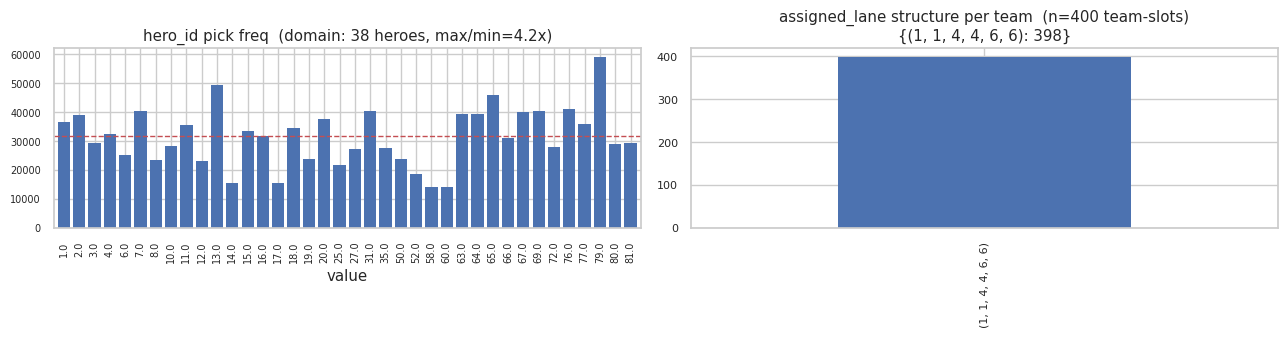

In [10]:
# hero_id domain + pick frequency
hero_cols = [f't{t}_p{p}_hero_id' for t in range(2) for p in range(6)]
hero_freq = df_clean[hero_cols].melt()['value'].value_counts().sort_index()

# assigned_lane: verify 2-2-2 structure in raw data
lane_structs = Counter()
for f in sorted(Path('../data/raw/matches').glob('*.json'))[:200]:
    if f.name == 'checkpoint.json': continue
    m = json.loads(f.read_text())
    for team in [0, 1]:
        lane_structs[tuple(sorted(p['assigned_lane'] for p in m['players'] if p['team'] == team))] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
hero_freq.plot.bar(ax=axes[0], edgecolor='none', width=0.8)
axes[0].axhline(hero_freq.mean(), color='r', lw=1, ls='--')
axes[0].set_title(f'hero_id pick freq  (domain: {len(hero_freq)} heroes, max/min={hero_freq.max()/hero_freq.min():.1f}x)')
axes[0].tick_params(labelsize=7)
pd.Series(lane_structs).plot.bar(ax=axes[1], edgecolor='none')
axes[1].set_title(f'assigned_lane structure per team  (n=400 team-slots)\n{dict(lane_structs)}')
axes[1].tick_params(labelsize=8)
plt.tight_layout()
plt.show()

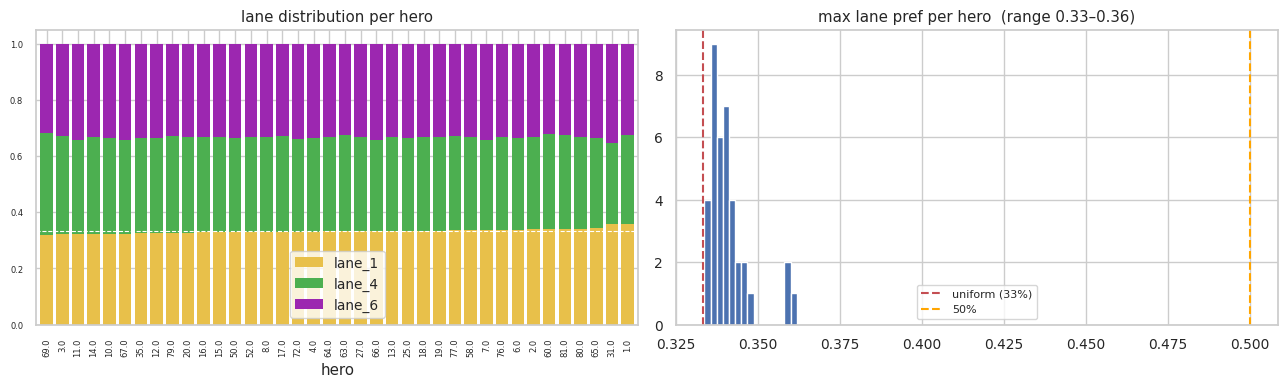

In [11]:
# hero × lane preference strength (use df — assigned_lane already dropped from df_clean)
pairs = pd.concat(
    [df[[f't{t}_p{p}_hero_id', f't{t}_p{p}_assigned_lane']].rename(
        columns={f't{t}_p{p}_hero_id': 'hero', f't{t}_p{p}_assigned_lane': 'lane'})
     for t in range(2) for p in range(6)], ignore_index=True)

lane_counts = pairs.groupby(['hero', 'lane']).size().unstack(fill_value=0)
lane_pct    = lane_counts.div(lane_counts.sum(axis=1), axis=0)
lane_pct.columns = [f'lane_{int(c)}' for c in lane_pct.columns]
max_lane_pref = lane_pct.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lane_pct.sort_values('lane_1').plot.bar(stacked=True, ax=axes[0], edgecolor='none', width=0.8,
    color=['#e8c04a', '#4caf50', '#9c27b0'], legend=True)
axes[0].axhline(1/3, color='w', lw=0.8, ls='--')
axes[0].set_title('lane distribution per hero')
axes[0].tick_params(labelsize=6)
max_lane_pref.hist(bins=15, ax=axes[1], edgecolor='white')
axes[1].axvline(1/3, color='r', lw=1.5, ls='--', label='uniform (33%)')
axes[1].axvline(0.5,  color='orange', lw=1.5, ls='--', label='50%')
axes[1].set_title(f'max lane pref per hero  (range {max_lane_pref.min():.2f}–{max_lane_pref.max():.2f})')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## correlation with label

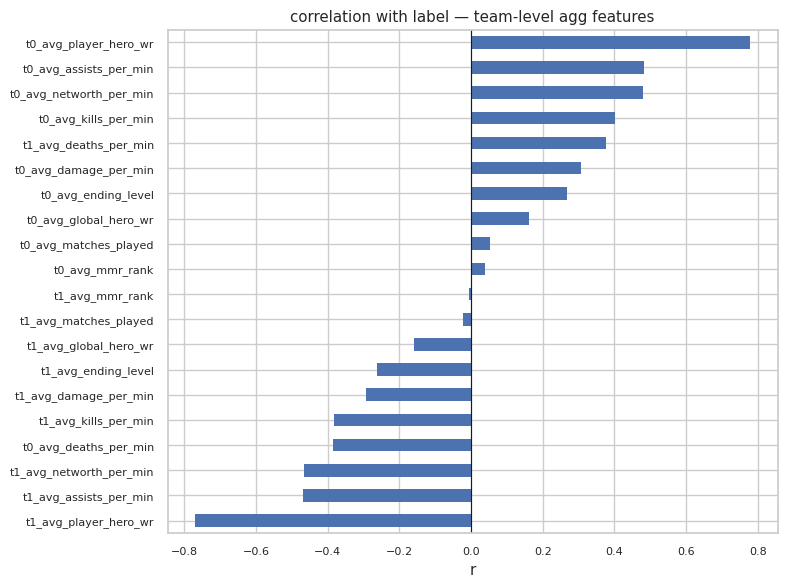

In [12]:
corr_df = df_clean[team_agg_cols].copy()
corr_df['label'] = y
label_corr = corr_df.corr()['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
label_corr.plot.barh(ax=ax, edgecolor='none')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('correlation with label — team-level agg features')
ax.set_xlabel('r')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

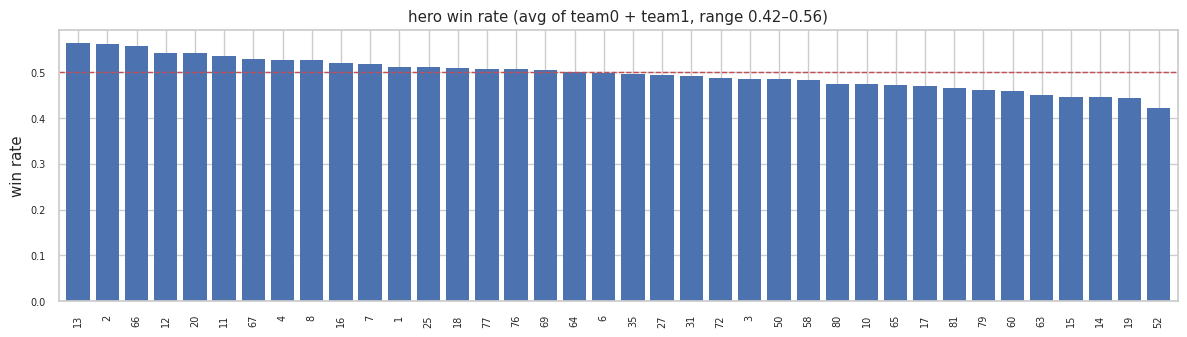

,wr_on_t0,wr_on_t1,n_t0,n_t1,wr_avg
13,0.570,0.558,25389.0,24025.0,0.564
2,0.567,0.557,20238.0,18873.0,0.562
66,0.566,0.548,15386.0,15640.0,0.557
20,0.547,0.536,18203.0,19506.0,0.541
12,0.546,0.539,11872.0,11364.0,0.542
11,0.539,0.533,17411.0,17970.0,0.536
4,0.534,0.520,15743.0,16685.0,0.527
67,0.531,0.527,19391.0,20451.0,0.529
16,0.530,0.508,15307.0,16264.0,0.519
8,0.527,0.524,11200.0,12239.0,0.526


In [13]:
# hero win rate — iterate over full hero domain (all slots, both teams)
_hero_cols = [f't{t}_p{p}_hero_id' for t in range(2) for p in range(6)]
_all_heroes = sorted(df[_hero_cols].stack().unique().astype(int))
hero_wr = {}
for hero in _all_heroes:
    # matches where this hero appears on team0 (any slot)
    mask_t0 = sum(df[f't0_p{p}_hero_id'] == hero for p in range(6)).astype(bool)
    # matches where this hero appears on team1
    mask_t1 = sum(df[f't1_p{p}_hero_id'] == hero for p in range(6)).astype(bool)
    wr_t0 = y[mask_t0].mean() if mask_t0.sum() > 100 else np.nan  # team0 win rate
    wr_t1 = 1 - y[mask_t1].mean() if mask_t1.sum() > 100 else np.nan  # team1 win rate (label=0)
    hero_wr[int(hero)] = {'wr_on_t0': wr_t0, 'wr_on_t1': wr_t1,
                          'n_t0': int(mask_t0.sum()), 'n_t1': int(mask_t1.sum())}

wr_df = pd.DataFrame(hero_wr).T.sort_values('wr_on_t0', ascending=False)
wr_df['wr_avg'] = wr_df[['wr_on_t0', 'wr_on_t1']].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
wr_df['wr_avg'].sort_values(ascending=False).plot.bar(ax=ax, edgecolor='none', width=0.8)
ax.axhline(0.5, color='r', lw=1, ls='--')
ax.set_title(f'hero win rate (avg of team0 + team1, range {wr_df["wr_avg"].min():.2f}–{wr_df["wr_avg"].max():.2f})')
ax.set_ylabel('win rate')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

display(wr_df.round(3))

## data splitting

In [14]:
from sklearn.model_selection import train_test_split

idx_tv, idx_test = train_test_split(
    np.arange(len(df_clean)), test_size=0.20, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.125, random_state=42, stratify=y.iloc[idx_tv])

X_train, y_train = df_clean.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = df_clean.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = df_clean.iloc[idx_test],  y.iloc[idx_test]

print(f"train {X_train.shape}, label=1: {y_train.mean():.3f}")
print(f"val   {X_val.shape}, label=1: {y_val.mean():.3f}")
print(f"test  {X_test.shape}, label=1: {y_test.mean():.3f}")

train (70027, 416), label=1: 0.505
val   (10004, 416), label=1: 0.505
test  (20008, 416), label=1: 0.505


## preprocessing pipeline

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['team_skill_gap'] = X['t0_avg_mmr_rank'] - X['t1_avg_mmr_rank']
        X['experience_gap'] = X['t0_avg_matches_played'] - X['t1_avg_matches_played']
        return X

class HeroMultiHot(BaseEstimator, TransformerMixin):
    """Encode 12 hero_id columns into 2×38 multi-hot vectors, drop originals."""
    def fit(self, X, y=None):
        hero_cols = [f't{t}_p{p}_hero_id' for t in range(2) for p in range(6)]
        self.hero_domain_ = sorted(X[hero_cols].stack().dropna().unique().astype(int))
        self.hero_to_idx_ = {h: i for i, h in enumerate(self.hero_domain_)}
        return self
    def transform(self, X):
        X = X.copy()
        hero_cols = [f't{t}_p{p}_hero_id' for t in range(2) for p in range(6)]
        for t in range(2):
            arr = np.zeros((len(X), len(self.hero_domain_)), dtype=np.int8)
            for p in range(6):
                for row_i, h in enumerate(X[f't{t}_p{p}_hero_id'].values):
                    if not np.isnan(h) and int(h) in self.hero_to_idx_:
                        arr[row_i, self.hero_to_idx_[int(h)]] = 1
            for i, h in enumerate(self.hero_domain_):
                X[f't{t}_hero_{h}'] = arr[:, i]
        X.drop(columns=hero_cols, inplace=True)
        return X
    def get_hero_feat_cols(self):
        return [f't{t}_hero_{h}' for t in range(2) for h in self.hero_domain_]

class Log1pSkewed(BaseEstimator, TransformerMixin):
    """log1p on cumulative stat columns, skip hero binary."""
    cumulative_fields = ['kills', 'deaths', 'assists', 'matches_played', 'wins', 'time_played']
    def fit(self, X, y=None):
        hero_cols = {c for c in X.columns if c.startswith('t0_hero_') or c.startswith('t1_hero_')}
        self.log_cols_ = sorted({
            c for c in X.columns
            if (any(c.endswith(f) or f'_{f}_' in c for f in self.cumulative_fields)
                or 'avg_matches_played' in c)
            and c not in hero_cols
        } & set(X.columns))
        return self
    def transform(self, X):
        X = X.copy()
        X[self.log_cols_] = np.log1p(X[self.log_cols_].clip(lower=0))
        return X

class ScaleContinuous(BaseEstimator, TransformerMixin):
    """Z-score continuous features, skip hero binary."""
    def fit(self, X, y=None):
        hero_cols = {c for c in X.columns if c.startswith('t0_hero_') or c.startswith('t1_hero_')}
        self.num_cols_ = [c for c in X.select_dtypes(include='number').columns if c not in hero_cols]
        self.scaler_ = StandardScaler().fit(X[self.num_cols_])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.num_cols_] = self.scaler_.transform(X[self.num_cols_])
        return X

class MedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.medians_ = X.median()
        return self
    def transform(self, X):
        return X.fillna(self.medians_)

pipeline = Pipeline([
    ('feat_eng',   FeatureEngineer()),
    ('hero_ohe',   HeroMultiHot()),
    ('impute',     MedianImputer()),
    ('log1p',      Log1pSkewed()),
    ('scale',      ScaleContinuous()),
])

X_train_processed = pipeline.fit_transform(X_train)
X_val_processed   = pipeline.transform(X_val)
X_test_processed  = pipeline.transform(X_test)

print(f"train {X_train_processed.shape}, val {X_val_processed.shape}, test {X_test_processed.shape}")
print(f"NaN: {X_train_processed.isna().sum().sum() + X_val_processed.isna().sum().sum() + X_test_processed.isna().sum().sum()}")

train (70027, 482), val (10004, 482), test (20008, 482)
NaN: 0


In [16]:
out_dir = Path('../data/processed')
X_train_processed.assign(label=y_train.values).to_parquet(out_dir / 'train.parquet', index=False)
X_val_processed.assign(label=y_val.values).to_parquet(out_dir / 'val.parquet', index=False)
X_test_processed.assign(label=y_test.values).to_parquet(out_dir / 'test.parquet', index=False)
print(f"saved to {out_dir}: train/val/test.parquet")

saved to ../data/processed: train/val/test.parquet
